### ANN: Task 6

In [28]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [29]:
#load
mnist = fetch_openml('mnist_784', version=1)
X = mnist.data.to_numpy()
y = mnist.target.astype(int).to_numpy() #converted to numpy and int
X = X / 255.0 #normalization

white = 0; Black = 1 --> [0,255] 
This gives smaller values allowing to learn faster and stablilize training.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=10000, random_state=42
) #tts

In [31]:
#onehotencode
def one_hot(y):
    one_hot = np.zeros((y.size,10))
    one_hot[np.arange(y.size), y] = 1
    return one_hot
y_train = one_hot(y_train)
y_test = one_hot(y_test)

Now to initialize weights and biases.
Weight(IP size, OP size)
Bias(1, OP size) -- NUMPY BROADCASTS



In [32]:
#weights initial
np.random.seed(42)
W1 = np.random.randn(784, 128) * np.sqrt(2 / 784)
b1 = np.zeros((1, 128))
W2 = np.random.randn(128, 64) * np.sqrt(2 / 128)
b2 = np.zeros((1, 64))
W3 = np.random.randn(64, 10) * np.sqrt(2 / 64)
b3 = np.zeros((1, 10))



In [33]:
def relu(x):
    return np.maximum(0,x) #x<0=0, x>=0=x
def relu_derivative(x):
    return (x > 0).astype(float)
def softmax(x):
    myexp = np.exp(x - np.max(x, axis=1, keepdims=True))
    return myexp / np.sum(myexp, axis=1, keepdims=True)

In [34]:
#forward pass
def forward(X):
    z1 = X.dot(W1) + b1
    a1 = relu(z1)
    z2 = a1.dot(W2) + b2
    a2 = relu(z2)
    z3 = a2.dot(W3) + b3
    a3 = softmax(z3)
    cache = (z1, a1, z2, a2, z3, a3)
    return a3, cache

In [35]:
#loss 
def compute_loss(Y, Y_hat):
    m = Y.shape[0]
    loss = -np.sum(Y * np.log(Y_hat + 1e-8)) / m
    return loss

backward pass will be put now


In [36]:
def backward(X, Y, cache):
    global W1, W2, W3
    Z1, A1, Z2, A2, Z3, A3 = cache
    m = X.shape[0]
    dZ3 = A3 - Y
    dW3 = A2.T @ dZ3 / m
    db3 = np.sum(dZ3, axis=0, keepdims=True) / m
    dA2 = dZ3 @ W3.T
    dZ2 = dA2 * relu_derivative(Z2)
    dW2 = A1.T @ dZ2 / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = X.T @ dZ1 / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m
    return dW1, db1, dW2, db2, dW3, db3


Use the revised parameters after backward pass now

In [37]:
def update_params(dW1, db1, dW2, db2, dW3, db3, lr):
    global W1, b1, W2, b2, W3, b3
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2
    W3 -= lr * dW3
    b3 -= lr * db3

Now train it

In [38]:
epochs = 20
lr = 0.1
batch_size = 64
for epoch in range(epochs):
    for i in range(0, X_train.shape[0], batch_size):
        X_batch = X_train[i:i+batch_size]
        y_batch = y_train[i:i+batch_size]
        Y_hat, cache = forward(X_batch)
        loss = compute_loss(y_batch, Y_hat)
        grads = backward(X_batch, y_batch, cache)
        update_params(*grads, lr)
    print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

Epoch 1, Loss: 0.1106
Epoch 2, Loss: 0.0840
Epoch 3, Loss: 0.0543
Epoch 4, Loss: 0.0457
Epoch 5, Loss: 0.0310
Epoch 6, Loss: 0.0253
Epoch 7, Loss: 0.0128
Epoch 8, Loss: 0.0079
Epoch 9, Loss: 0.0071
Epoch 10, Loss: 0.0067
Epoch 11, Loss: 0.0056
Epoch 12, Loss: 0.0034
Epoch 13, Loss: 0.0072
Epoch 14, Loss: 0.0085
Epoch 15, Loss: 0.0052
Epoch 16, Loss: 0.0020
Epoch 17, Loss: 0.0023
Epoch 18, Loss: 0.0015
Epoch 19, Loss: 0.0013
Epoch 20, Loss: 0.0011


In [39]:
#Prediction
def predict(X):
    Y_hat, _ = forward(X)
    return np.argmax(Y_hat, axis=1)

Visualise the entire ANN

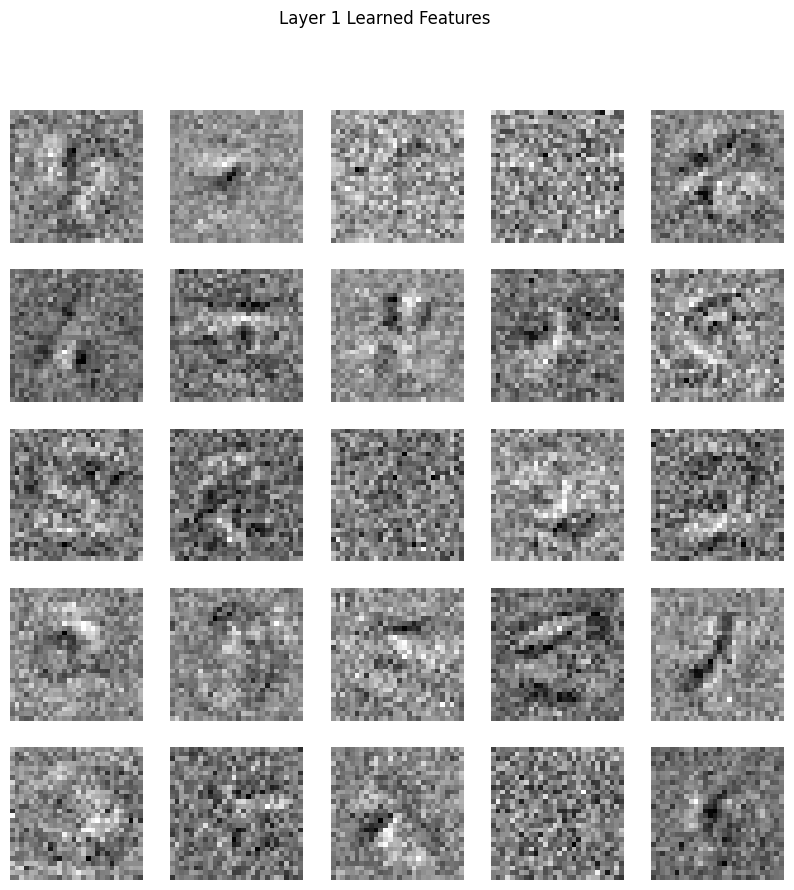

In [41]:
def visualize_weights(W1):
    plt.figure(figsize=(10,10))
    for i in range(25):
        plt.subplot(5,5,i+1)
        img = W1[:,i].reshape(28,28)
        img = (img - img.min()) / (img.max() - img.min())
        plt.imshow(img, cmap='gray')
        plt.axis('off')
    plt.suptitle("Layer 1 Learned Features")
    plt.show()
visualize_weights(W1)